# Friedel Pair Matching (Preprocessed HDF5)

Compare the first 5 preprocessed frames with their Friedel-pair partners at +1800 frame offset.
The right image is flipped vertically so spots have matching direction for easier identification.

In [1]:
from pathlib import Path
import h5py
import hdf5plugin  # noqa: F401
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Circle
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, binary_opening, disk
from scipy.spatial.distance import cdist


In [ ]:
DATA_ROOT = Path(r"../data_esrf/")

# Same dataset registry pattern as in inspect_data
DATASETS = {
    "Al": {"main": "_iris_iris_500_cont.h5", "pre": "full.h5"},
    "Al_big_grains": {"main": "Al1050_dct7p5_Al1050_dct7p.h5"},
    "Al_deformed_LoG": {
        "main": "A2050_as_annealed_DT_W370_0p12_strain_dct3_A2050_as_annealed_DT_W370_0p12_strain_dct.h5",
        "log_tar": "A2050_as_annealed_DT_W370_0p12_strain_dct3.tar",
    },
    "Al_small_grains": {"main": "iris_dct_450C_0003_iris_dct_450C.h5"},
    "Cu": {"main": "copper3_dct_load1_redo_copper3_dct_load1_redo.h5"},
    "IN718_twins": {"main": "ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5"},
    "Iron": {"main": "ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5"},
    "Iron_deformed": {"main": "pureIron2_dct_2nd_load_z1_pureIron2_dct_2nd_load_z.h5"},
    "Ti7Al": {"main": "sam_23_dct4_sam_23_dct.h5"},
}

MATERIAL = "Al"  # change as needed
entry = DATASETS[MATERIAL]
SCAN_DIR = DATA_ROOT / MATERIAL
PRE_KEY = entry.get("pre_key", "image/data")

if "pre" not in entry:
    raise ValueError(f"No preprocessed file registered for {MATERIAL}.")

pre_path = SCAN_DIR / entry["pre"]
print(f"Using preprocessed file: {pre_path}")
print(f"Dataset key: {PRE_KEY}")

Using preprocessed file: ../data_esrf/Al/full.h5
Dataset key: image/data


full shape=(3672, 2048, 2048) dtype=float32


/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is depre

Frame 1201: left mask pixels=25320  right mask pixels=17073


/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is depre

Frame 1202: left mask pixels=40904  right mask pixels=32619


/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is depre

Frame 1203: left mask pixels=18537  right mask pixels=38355


/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is depre

Frame 1204: left mask pixels=28393  right mask pixels=24472


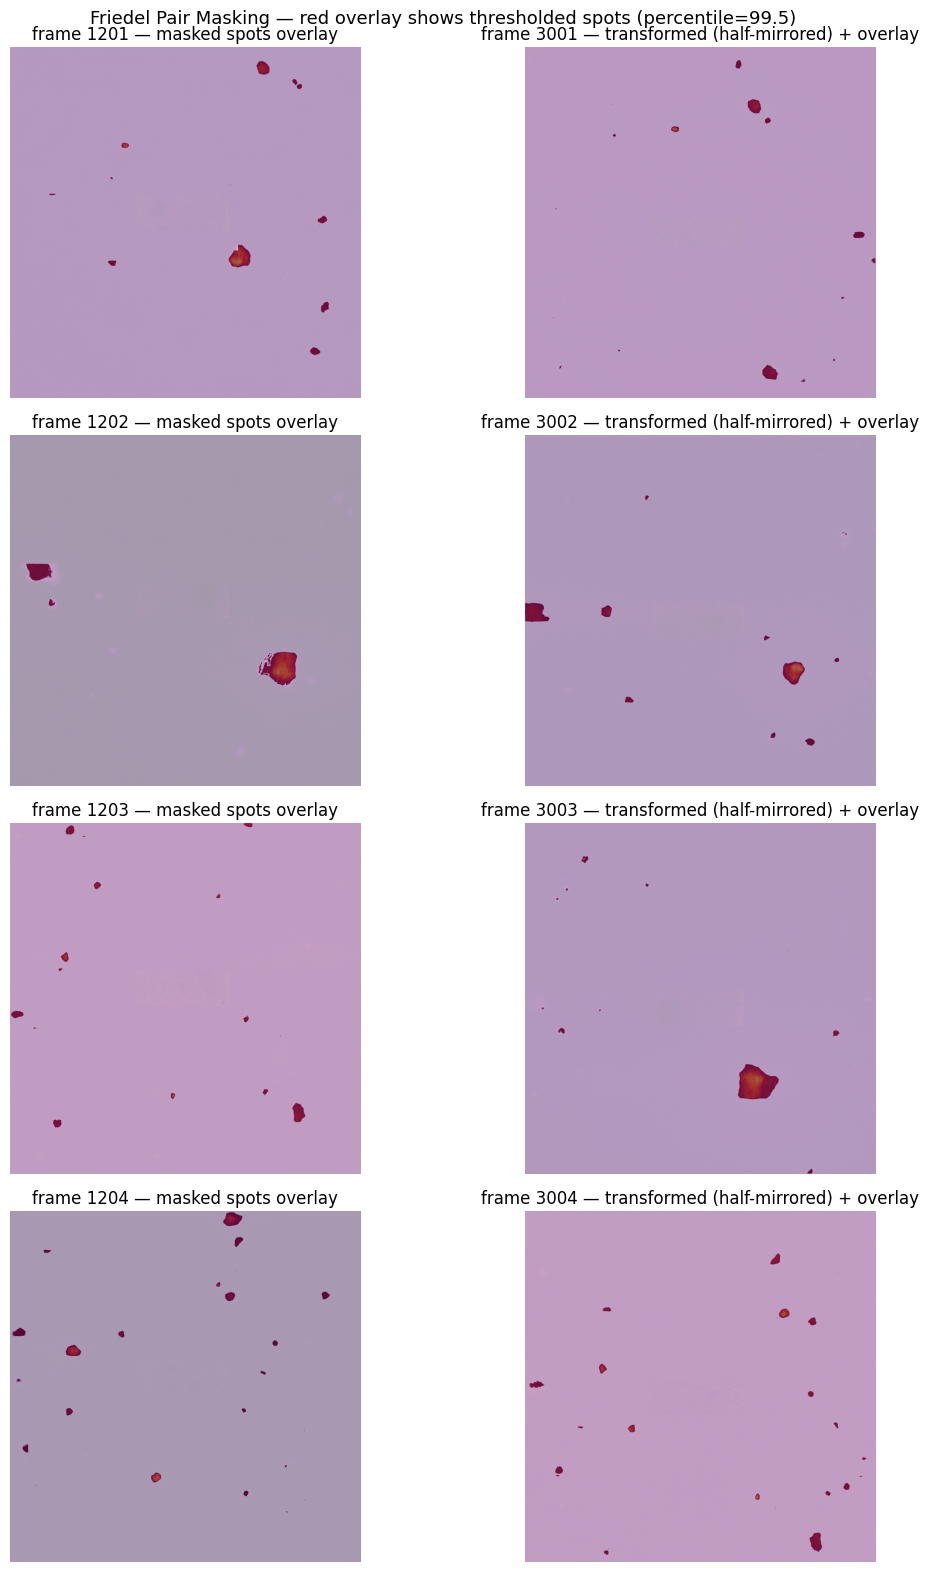

In [9]:
if not pre_path.exists():
    raise FileNotFoundError(f"Preprocessed file not found: {pre_path}")

first_indices = list(range(1201, 1205))
friedel_offset = 1800
pair_indices = [i + friedel_offset for i in first_indices]

with h5py.File(pre_path, "r") as f:
    pre = f[PRE_KEY]
    print(f"full shape={pre.shape} dtype={pre.dtype}")

    max_idx = max(pair_indices)
    if max_idx >= pre.shape[0]:
        raise IndexError(
            f"Requested index {max_idx} but dataset only has {pre.shape[0]} frames"
        )

    # two columns: left image with overlay, right transformed image with overlay
    fig, axes = plt.subplots(len(first_indices), 2, figsize=(12, 4 * len(first_indices)))
    if len(first_indices) == 1:
        axes = np.array([axes])

    for row, (i_left, i_right) in enumerate(zip(first_indices, pair_indices)):
        img_left = pre[i_left]
        img_right = pre[i_right]

        # Create transformed right image (half-mirrored as implemented earlier)
        h, w = img_right.shape[:2]
        mid = h // 2
        if h % 2 == 0:
            top = img_right[:mid, :].copy()
            bottom = img_right[mid:, :].copy()
            new_img = np.vstack((np.flipud(bottom), np.flipud(top)))
        else:
            top = img_right[:mid, :].copy()
            center = img_right[mid:mid+1, :].copy()
            bottom = img_right[mid+1:, :].copy()
            new_img = np.vstack((np.flipud(bottom), center, np.flipud(top)))

        # compute masks (adjust percentile if needed)
        mask_left = compute_mask(img_left, perc=99)
        mask_right = compute_mask(new_img, perc=99)

        print(f"Frame {i_left}: left mask pixels={mask_left.sum()}  right mask pixels={mask_right.sum()}")

        # left: original with red overlay for mask
        axes[row, 0].imshow(img_left, cmap="magma")
        axes[row, 0].imshow(mask_left, cmap="Reds", alpha=0.6)
        axes[row, 0].set_title(f"frame {i_left} — masked spots overlay")
        axes[row, 0].axis("off")

        # right: transformed image with red overlay for mask
        axes[row, 1].imshow(new_img, cmap="magma")
        axes[row, 1].imshow(mask_right, cmap="Reds", alpha=0.6)
        axes[row, 1].set_title(f"frame {i_right} — transformed (half-mirrored) + overlay")
        axes[row, 1].axis("off")

    fig.suptitle("Friedel Pair Masking — red overlay shows thresholded spots (percentile=99.5)", fontsize=13)
    plt.tight_layout()
    plt.show()

In [8]:
def compute_mask(img, perc=99.5, min_size=5):
    imgf = img.astype(np.float32)

    thr = np.percentile(imgf, perc)

    mask = imgf > thr

    mask = binary_opening(mask, disk(1))
    mask = remove_small_objects(mask, min_size=min_size)

    # remove reflector
    mask = remove_center_reflector(mask, img.shape)

    return mask

def remove_center_reflector(mask, img_shape,
                            x_frac=(0.35, 0.65),
                            y_frac=(0.42, 0.58)):

    h, w = img_shape

    x1 = int(w * x_frac[0])
    x2 = int(w * x_frac[1])

    y1 = int(h * y_frac[0])
    y2 = int(h * y_frac[1])

    mask[y1:y2, x1:x2] = False

    return mask


def extract_spots(img, frame_idx, perc=99, min_size=10, max_size=2000):
    imgf = img.astype(np.float32)

    mask = compute_mask(imgf, perc=perc, min_size=min_size)
    lab = label(mask)

    rows = []

    for k, r in enumerate(regionprops(lab, intensity_image=imgf)):
        if r.area < min_size:
            continue

        if r.area > max_size:
            continue

        minr, minc, maxr, maxc = r.bbox
        y, x = r.weighted_centroid

        total_intensity = r.intensity_image[r.image].sum()
        max_intensity = r.max_intensity
        mean_intensity = r.mean_intensity

        rows.append({
            "frame": frame_idx,
            "spot_id": k,
            "x": float(x),
            "y": float(y),
            "area": float(r.area),
            "total_intensity": float(total_intensity),
            "mean_intensity": float(mean_intensity),
            "max_intensity": float(max_intensity),
            "eccentricity": float(r.eccentricity),
            "solidity": float(r.solidity),
            "bbox": (minr, minc, maxr, maxc),
        })

    df = pd.DataFrame(rows)

    if len(df) > 0:
        df = df.sort_values(
            ["total_intensity", "area"],
            ascending=False
        ).reset_index(drop=True)

    return df, mask


def spot_match_score(a, b):
    """
    Smaller is better.
    Compares position, size, and rough shape.
    """

    pos_dist = np.sqrt((a["x"] - b["x"])**2 + (a["y"] - b["y"])**2)

    area_ratio = abs(np.log((a["area"] + 1) / (b["area"] + 1)))
    ecc_diff = abs(a["eccentricity"] - b["eccentricity"])
    sol_diff = abs(a["solidity"] - b["solidity"])

    bbox_h_ratio = abs(np.log((a["bbox_h"] + 1) / (b["bbox_h"] + 1)))
    bbox_w_ratio = abs(np.log((a["bbox_w"] + 1) / (b["bbox_w"] + 1)))

    score = (
        1.0 * pos_dist +
        15.0 * area_ratio +
        10.0 * ecc_diff +
        10.0 * sol_diff +
        8.0 * bbox_h_ratio +
        8.0 * bbox_w_ratio
    )

    return score

def get_patch(img, x, y, size=31):
    """
    Extract square patch centered at x/y.
    Pads image borders if needed.
    """
    img = img.astype(np.float32)

    r = size // 2
    x = int(round(x))
    y = int(round(y))

    padded = np.pad(img, r, mode="constant", constant_values=0)

    yp = y + r
    xp = x + r

    patch = padded[yp-r:yp+r+1, xp-r:xp+r+1]

    return patch

In [45]:
def normalize_patch(patch):
    patch = patch.astype(np.float32)

    patch = patch - np.percentile(patch, 20)
    patch[patch < 0] = 0

    s = patch.sum()
    if s > 0:
        patch = patch / s

    return patch


def patch_distance(p1, p2):
    p1 = normalize_patch(p1)
    p2 = normalize_patch(p2)

    return np.mean((p1 - p2) ** 2)


# def best_patch_distance(p1, p2):
#     """
#     Compare normal
#     Smaller is better.
#     """
#     variants = [
#         p2
#     ]

#     distances = [patch_distance(p1, v) for v in variants]
#     best_idx = int(np.argmin(distances))


#     return distances[best_idx]

In [46]:
def patch_distance_shifted(p1, p2, max_shift=4):
    """
    Compare two patches while allowing small x/y shifts.
    Smaller distance = better match.
    """

    best_dist = np.inf
    best_shift = (0, 0)

    for dy in range(-max_shift, max_shift + 1):
        for dx in range(-max_shift, max_shift + 1):

            shifted = np.roll(p2, shift=(dy, dx), axis=(0, 1))

            dist = patch_distance(p1, shifted)

            if dist < best_dist:
                best_dist = dist
                best_shift = (dy, dx)

    return best_dist, best_shift

In [52]:
def friedel_score(a, b, img_left, img_right, patch_size=35):
    p1 = get_patch(img_left, a["x"], a["y"], size=patch_size)
    p2 = get_patch(img_right, b["x"], b["y"], size=patch_size)

    shape_dist, patch_shift = patch_distance_shifted(p1, p2)

    area_diff = abs(np.log((a["area"] + 1) / (b["area"] + 1)))
    intensity_diff = abs(np.log((a["total_intensity"] + 1) / (b["total_intensity"] + 1)))

    score = (
        3000 * shape_dist +
        15 * area_diff +
        15 * intensity_diff
    )

    return score, shape_dist

In [53]:
def match_friedel_candidates(
    pre,
    left_indices,
    right_indices,
    frame_tolerance=2,
    perc=98.5,
    min_size=5000,
    max_size=50000,
    max_spots_per_frame=25,
    max_score=80,
    patch_size=35,
):
    results = []

    for i_left, i_right_nominal in zip(left_indices, right_indices):
        img_left = np.asarray(pre[i_left]).astype(np.float32)

        spots_left, _ = extract_spots(
            img_left,
            i_left,
            perc=perc,
            min_size=min_size,
            max_size=max_size
        )

        if len(spots_left) == 0:
            continue

        for i_right in range(
            i_right_nominal - frame_tolerance,
            i_right_nominal + frame_tolerance + 1
        ):
            if i_right < 0 or i_right >= pre.shape[0]:
                continue

            img_right_raw = np.asarray(pre[i_right]).astype(np.float32)
            img_right = np.fliplr(img_right_raw)

            spots_right, _ = extract_spots(
                img_right,
                i_right,
                perc=perc,
                min_size=min_size,
                max_size=max_size
            )

            if len(spots_right) == 0:
                continue

            for _, a in spots_left.iterrows():
                best = None

                for _, b in spots_right.iterrows():
                    score, shape_dist = friedel_score(
                        a,
                        b,
                        img_left,
                        img_right,
                        patch_size=patch_size
                    )

                    if best is None or score < best["score"]:
                        best = {
                            "left_frame": i_left,
                            "right_frame": i_right,
                            "left_spot_id": int(a["spot_id"]),
                            "right_spot_id": int(b["spot_id"]),
                            "left_x": float(a["x"]),
                            "left_y": float(a["y"]),
                            "right_x": float(b["x"]),
                            "right_y": float(b["y"]),
                            "left_area": float(a["area"]),
                            "right_area": float(b["area"]),
                            "left_total_intensity": float(a["total_intensity"]),
                            "right_total_intensity": float(b["total_intensity"]),
                            "shape_distance": float(shape_dist),
                            "score": float(score),
                        }

                if best is not None:
                    results.append(best)

    matches = pd.DataFrame(results)

    if len(matches) > 0:
        matches = matches.sort_values(
            ["left_frame", "score", "shape_distance"],
            ascending=True
        ).reset_index(drop=True)

    return matches

In [54]:
with h5py.File(pre_path, "r") as f:
    pre = f[PRE_KEY]

    matches = match_friedel_candidates(
        pre,
        first_indices,
        pair_indices,
        frame_tolerance=1,
        perc=99,
        min_size=5000,
        max_size=50000,
        max_spots_per_frame=20,
        max_score=90,
        patch_size=41,
    )

print(matches.to_string(index=False))

/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/tmp/ipykernel_1818/2100093037.py:49: FutureWarning: `RegionProperties.weighted_centroid` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.centroid_weighted` instead. 
  y, x = r.weighted_centroid
/tmp/ipykernel_1818/2100093037.py:51: FutureWarning: `Re

 left_frame  right_frame  left_spot_id  right_spot_id      left_x      left_y     right_x     right_y  left_area  right_area  left_total_intensity  right_total_intensity  shape_distance     score
       1201         3002             0              0 1339.207151 1230.686905  477.202441  668.533983    11486.0     12218.0             3037038.0              4261165.0    6.875019e-08  6.006746
       1201         3001             0              0 1339.207151 1230.686905  615.618375  146.414176    11486.0      5426.0             3037038.0               607355.0    3.854723e-07 35.391446
       1202         3002             0              1  167.480634  793.346278 1993.740144 1008.455703    11078.0     12064.0             2658974.0              2084160.0    2.876996e-07  4.933337
       1202         3003             1              0 1590.782202 1358.078741  706.664381  528.711373    27685.0     34532.0            13205664.0             10730507.0    2.346907e-07  6.428857
       1202         

/tmp/ipykernel_1818/2100093037.py:8: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = binary_opening(mask, disk(1))
/tmp/ipykernel_1818/2100093037.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/tmp/ipykernel_1818/2100093037.py:49: FutureWarning: `RegionProperties.weighted_centroid` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.centroid_weighted` instead. 
  y, x = r.weighted_centroid
/tmp/ipykernel_1818/2100093037.py:51: FutureWarning: `Re

In [50]:
def mark_spot(ax, x, y, radius=200):
    circ = Circle(
        (x, y),
        radius=radius,
        fill=False,
        edgecolor="cyan",
        linewidth=1.5
    )
    ax.add_patch(circ)

def show_match_from_file(pre_path, PRE_KEY, match):
    with h5py.File(pre_path, "r") as f:
        pre = f[PRE_KEY]

        lf = int(match["left_frame"])
        rf = int(match["right_frame"])

        left = np.asarray(pre[lf])
        right = np.fliplr(pre[rf])

    lx, ly = match["left_x"], match["left_y"]
    rx, ry = match["right_x"], match["right_y"]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(left, cmap="magma")
    mark_spot(axes[0], lx, ly)
    axes[0].set_title(f"left frame {lf}")
    axes[0].axis("off")

    axes[1].imshow(right, cmap="magma")
    mark_spot(axes[1], rx, ry)
    axes[1].set_title(f"right frame {rf}, transformed")
    axes[1].axis("off")

    plt.suptitle(
        f"score={match['score']:.2f}"
    )
    plt.tight_layout()
    plt.show()

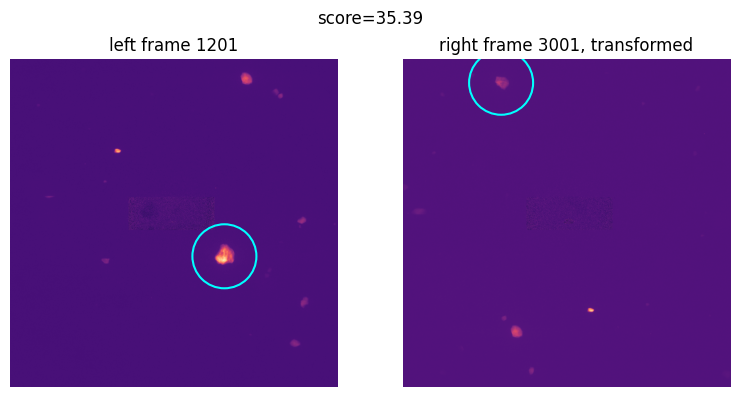

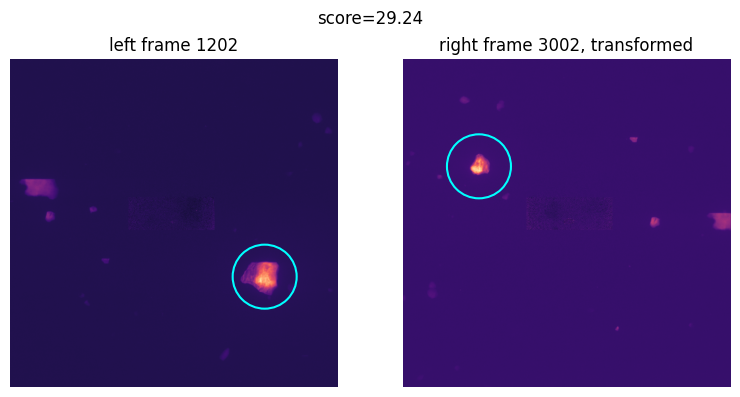

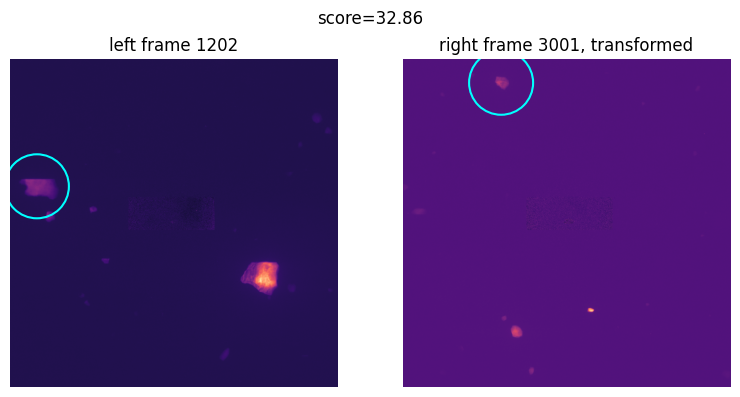

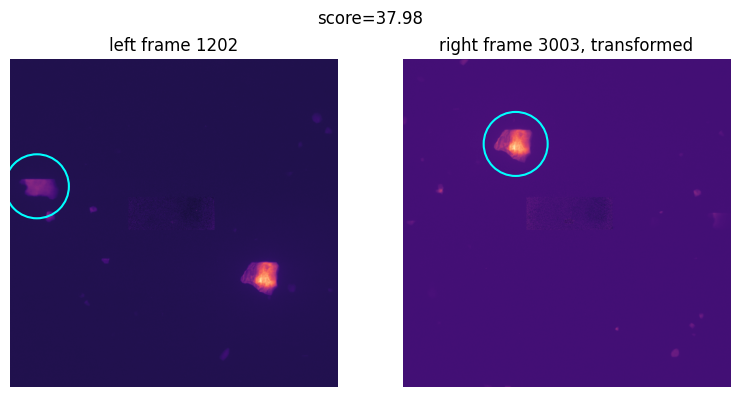

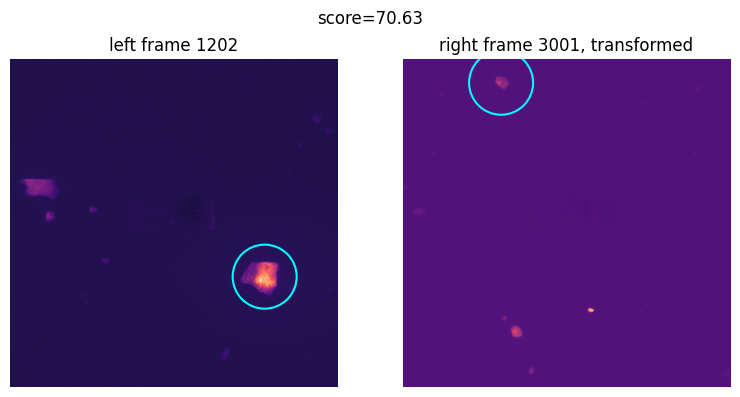

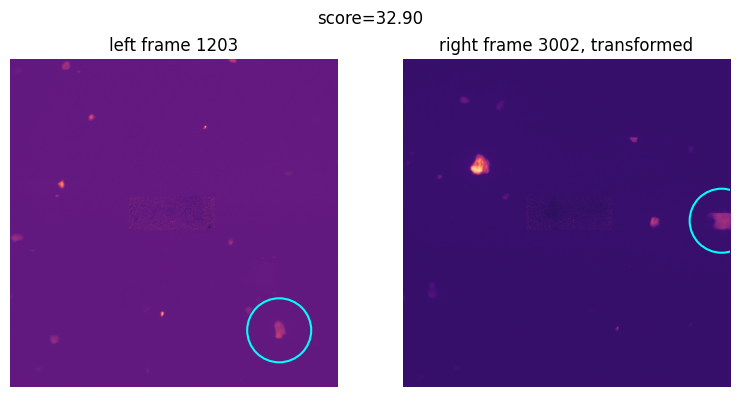

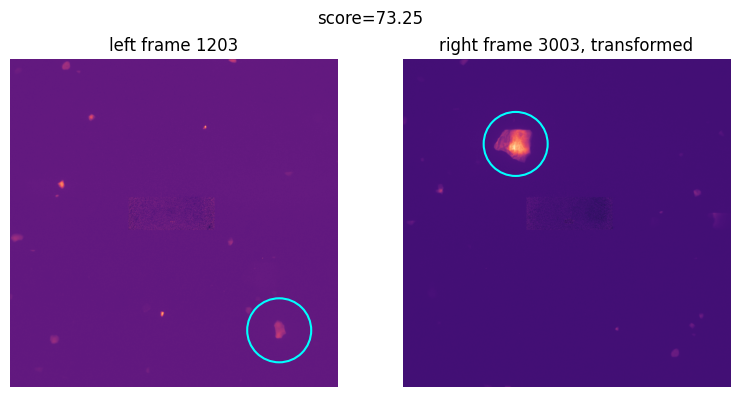

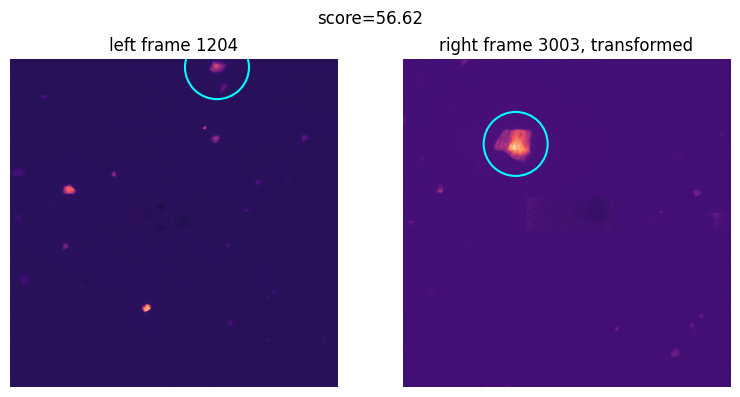

In [55]:
filtered = matches[matches["score"] > 20]

for _, m in filtered.iterrows():
    show_match_from_file(pre_path, PRE_KEY, m)